<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Metodos-computacionales/Tarea3_MC_Juanmanuel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files
from tqdm import tqdm
%matplotlib inline

<br>

## **P1. Lectura y subida de datos:**

In [ ]:
# subir los datos (nombre: datos.txt)
fil = files.upload()

Saving datos.txt to datos (2).txt


In [ ]:
hor = 1/(60*60) # conversion seg a horas

# Leer los datos por pandas
datos = pd.read_csv('datos.txt',sep=' ',header=None) # datos separados por ' ' sin encabezado

# Columnas
t = np.array(datos[0]) *hor # tiempo [h]
x = np.array(datos[1])      # posicion x(t)
y = np.array(datos[2])      # posicion y(t)

## **A)  Interpolacion Lineal**

In [ ]:
def Interpolacion_lineal(xi,yi, n):  # forma 1
   xl=[] ; yl=[]
   for i in range(len(xi)-1):
      x = np.linspace(xi[i],xi[i+1],n)  # intervalos i,i+1 en n pedasos (endpoint=False:excluye último punto)
      f = lambda x: yi[i]+(yi[i+1]-yi[i])/(xi[i+1]-xi[i])*(x-xi[i]) # interpolacion lineal en i,i+1
      y = np.array([ f(i) for i in x ]) # datos interpolados en el intervalo i,i+1

      xl = xl + list(x)
      yl = yl + list(y)
   return xl, yl                        # retorna las listas del rango y su interpolacion
# inter_x = Interpolacion_lineal(t,x,n=10) # n puntos
# inter_y = Interpolacion_lineal(t,y,n=10)

In [ ]:
def inter_lineal(x_int,xn,yn):    # forma 2 (requiere un punto adicional para interpolar)
  N=len(xn)
  y_int=0
  for i in range(N-1):
    if x_int>=xn[i] and x_int<=xn[i+1]:
      y_int=(yn[i+1]-yn[i])/(xn[i+1]-xn[i])*(x_int-xn[i])+yn[i]
      break
  return y_int                    # retorna solo 1 punto de interpolacion

t_real = np.linspace(min(t),max(t),10000)  # dominio de interpolacion
y_list = np.zeros( len(t_real) )  # array para los datos interpolados y
x_list = np.zeros( len(t_real) )  # array para los datos interpolados x

for k in range( len(t_real) ):    # requiere de un for para obtener interpol completa
  y_list[k] = inter_lineal( t_real[k], t,y)
  x_list[k] = inter_lineal( t_real[k], t,x)

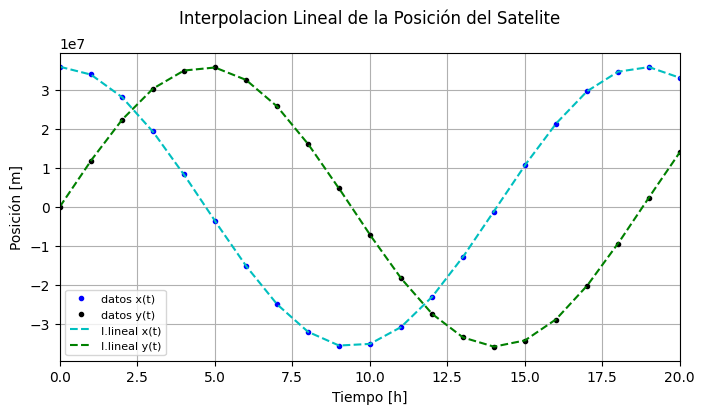

In [ ]:
# Grafica
plt.figure(figsize=(8,4))
plt.plot(t,x,'bo',label='datos x(t)', markersize=3)  # datos x
plt.plot(t,y,'ko',label='datos y(t)', markersize=3)  # datos y
plt.plot(t_real,x_list,'c--',label='I.lineal x(t)' ) # interpolacion x
plt.plot(t_real,y_list,'g--',label='I.lineal y(t)')  # interpolacion y

plt.title('Interpolacion Lineal de la Posición del Satelite\n')
plt.xlabel('Tiempo [h]')
plt.ylabel('Posición [m]')
plt.xlim(min(t),max(t))
plt.legend(fontsize=8)
plt.grid()

## **B ) Raices y Periodo del satelite en horas**

In [ ]:
def  Secante(f,p0,p1,eps=1e-5,Nmax=100): # Raices Metodo Secante
   q0 = f(p0); q1 = f(p1); i = 2

   while i<Nmax:
      p = p1 - q1*(p1 - p0)/(q1 - q0)
      #print (i, p, f(p))

      if ( np.abs(p - p1) < eps ): break # condición de parada.
      i = i + 1

      p0 = p1
      q0 = q1
      p1 = p
      q1 = f(p)
      if (i == Nmax): print ("el método fallo")
   return p

El periodo del satelite (en x) es: T_x = 18.811 horas
El periodo del satelite (en y) es: T_y = 18.803 horas




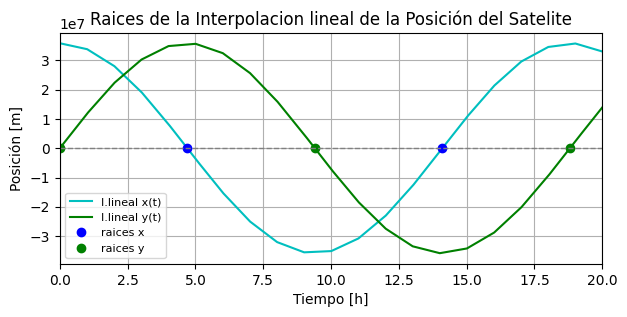

In [ ]:
# Funciones a evaluar en el metodo de raices
def fun_x(p0): return inter_lineal(p0,t,x)
def fun_y(p0): return inter_lineal(p0,t,y)

s1_x = Secante(fun_x, 2.5,7.5, 1e-5)  # Raices x
s2_x = Secante(fun_x, 12.5,17.5, 1e-5)
s1_y = Secante(fun_y, 7.5,12.5, 1e-5) # Raices y
s2_y = Secante(fun_y, 15,19, 1e-5)
s0_y = Secante(fun_y, 0,2.5, 1e-5)

# Grafica
plt.figure(figsize=(7,3))
plt.plot(t_real,x_list,'c',label='I.lineal x(t)' ) # interpolacion x
plt.plot(t_real,y_list,'g',label='I.lineal y(t)')  # interpolacion y
plt.plot(s1_x,fun_x(s1_x),'bo', label='raices x')  # raiz 1 x
plt.plot(s2_x,fun_x(s2_x),'bo')                    # raiz 2 x
plt.plot(s1_y,fun_y(s1_y),'go', label='raices y')  # raiz 1 y
plt.plot(s2_y,fun_y(s2_y),'go')                    # raiz 2 y
plt.plot(s0_y,fun_y(s0_y),'go')                    # raiz 0 y

plt.title('Raices de la Interpolacion lineal de la Posición del Satelite')
plt.xlabel('Tiempo [h]')
plt.ylabel('Posición [m]')
plt.hlines(0,0,max(t), colors='gray',linestyles='dashed', lw=1)
plt.xlim(min(t),max(t))
plt.legend(fontsize=8)
plt.grid()

# Periodo T:
T_x = 2*(s2_x -s1_x) # como solo se tienen 2 raices consecutivas para obtener T es el doble de la distancia de las consecutivas
T_y = (s2_y -s0_y)

print(f'El periodo del satelite (en x) es: T_x = {T_x:.5} horas')
print(f'El periodo del satelite (en y) es: T_y = {T_y:.5} horas')
print('\n')

### **C) Error:**

In [ ]:
r = lambda t: fun_x(t) + fun_y(t) # vector r
T = (T_x + T_y)/2                 # periodo promedio
err = np.abs(r(T) - r(0))

print(f'El error de la posición interpolada tras un periodo es: {err:.8} m')

El error de la posición interpolada tras un periodo es: 265159.94 m


### **D) Discusión**
<p align="justify">
Este error depende de los periodos $T$, que a su vez dependen de las raices de la funcion de interpolacion lineal encontradas; luego una manera de reducir el error tras un periodo, sería tomando otro tipo de interpolacion mas adecuda que la lineal, una polinomica que se ajuste mas al tipo de curva descrita por la trayectoria del satelite en funcion del tiempo, de modo que los valores de las raices sean mas precisos. </p>


<br>

## **P2.** Comparacion de metodos interpolacion: **Lineal, Lagrange y Diferencias Divididas**

In [ ]:
def interpolacion_lagrange(x_int,xn,yn): # Interpolacion metodo Lagrange
  N=len(xn)
  #Grado
  n=N-1

  def L(x,n,i):
    prod=1
    for m in range(n+1):
      if m!=i:
        prod*=(x-xn[m])/(xn[i]-xn[m])
    return prod

  suma=0
  for i in range(n+1):
    suma+=yn[i]*L(x_int,n,i)

  return suma

In [ ]:
def interpolacion_Diferencias(x_int,xn,yn): # Interpolacion diferencias divididas
    n=len(xn)-1
    D=np.zeros((n+1,n+1)) #D[k,x_i]
    D[0,:]=yn

    for k in range(1,n+1):
        for i in range(0,n+1-k):
            D[k,i]=(D[k-1,i+1]-D[k-1,i])/(xn[i+k]-xn[i])
    suma=D[0,0]

    for k in range(1,n+1):
        prod=1.
        for p in range(0,k):
            prod*=(x_int-xn[p])
        suma+=D[k,0]*prod

    return suma

In [ ]:
# Datos
n = 15                         # numero de datos
xn = np.linspace(0,6*np.pi,n) # x_n puntos
yn = np.sin(xn)               # y_n puntos

# Datos interpolacion
x_real = np.linspace(0, 6*np.pi, 100) # dominio interpolacion
y_real = np.sin(x_real)               # valor real del rango

y_lin = np.zeros(len(x_real)) # arreglos para la interpolacion lineal
y_lag = np.zeros(len(x_real)) # Lagrange
y_dd = np.zeros(len(x_real))  # Dif divididas


for k in range(len(x_real)): # iteracion para interpolacion completa
  y_lag[k] = interpolacion_lagrange( x_real[k], xn,yn)
  y_lin[k] = inter_lineal( x_real[k], xn,yn)
  y_dd[k]  = interpolacion_Diferencias( x_real[k],xn,yn)

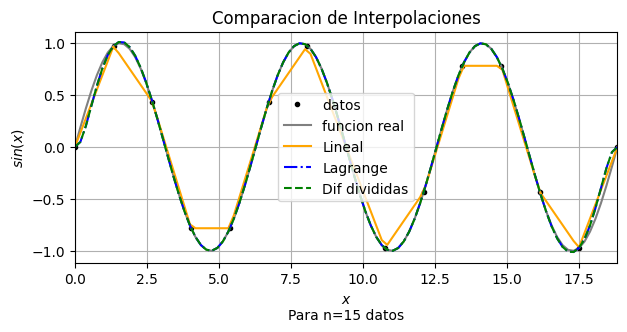

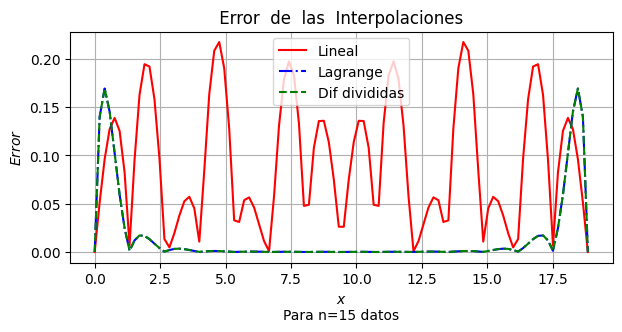

In [ ]:
plt.figure(figsize=(7,3))
plt.plot(xn,yn,'k.',label='datos')
plt.plot(x_real,y_real,'gray',label='funcion real')
plt.plot(x_real,y_lin,'orange', label='Lineal')
plt.plot(x_real,y_lag,'b-.',label='Lagrange')
plt.plot(x_real,y_dd,'g--',label='Dif divididas')

plt.title('Comparacion de Interpolaciones')
plt.ylabel('$sin(x)$')
plt.xlabel(f'$x$\nPara n={n} datos')
plt.xlim(min(x_real),max(x_real))
plt.legend()
plt.grid()

# Error de las interpolaciones
err_lin = abs((y_real-y_lin))
err_lag = abs((y_real-y_lag))
err_dd  = abs((y_real-y_dd))

plt.figure(figsize=(7,3))
plt.title(' Error  de  las  Interpolaciones ')
plt.ylabel('$Error$')
plt.xlabel(f'$x$\nPara n={n} datos')
plt.plot(x_real,err_lin,'r',label='Lineal')
plt.plot(x_real,err_lag,'b-.',label='Lagrange')
plt.plot(x_real,err_dd,'g--',label='Dif divididas')
plt.legend()
plt.grid()

100%|██████████| 48/48 [00:05<00:00,  9.19it/s]


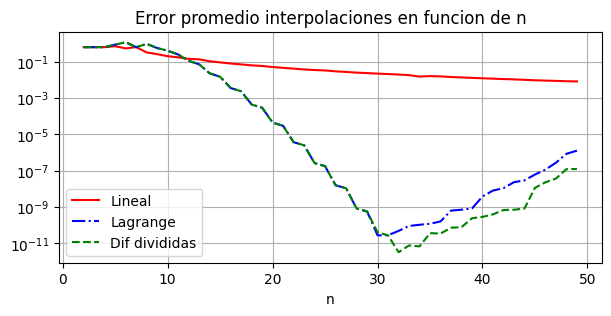

In [ ]:
N = np.arange(2,50,1) # lista de valores de n (desde 1 dato no tiene sentido)
eprom_lin_list = []   # listas errores prom funcion de n
eprom_lag_list = []
eprom_dd_list  = []

for i in tqdm(range(len(N))): # iteracion en funcion de n
  xn = np.linspace(0,6*np.pi, N[i]) # x_n puntos
  yn = np.sin(xn)               # y_n puntos

  # Datos interpolacion
  x_real = np.linspace(0, 6*np.pi, 100) # dominio interpolacion
  y_real = np.sin(x_real)               # valor real del rango

  y_lin = np.zeros(len(x_real)) # arreglos para la interpolacion lineal
  y_lag = np.zeros(len(x_real)) # Lagrange
  y_dd = np.zeros(len(x_real))  # Dif divididas


  for k in (range(len(x_real))): # iteracion para interpolacion completa
    y_lag[k] = interpolacion_lagrange( x_real[k], xn,yn)
    y_lin[k] = inter_lineal( x_real[k], xn,yn)
    y_dd[k]  = interpolacion_Diferencias( x_real[k],xn,yn)

  err_lin = abs((y_real-y_lin)) # errores
  err_lag = abs((y_real-y_lag))
  err_dd  = abs((y_real-y_dd))

  eprom_lin = sum(err_lin)/len(err_lin) # errores promedio
  eprom_lag = sum(err_lag)/len(err_lag)
  eprom_dd  = sum(err_dd)/len(err_dd)

  eprom_lin_list.append( eprom_lin)
  eprom_lag_list.append( eprom_lag)
  eprom_dd_list.append( eprom_dd)


plt.figure(figsize=(7,3))
plt.plot(N,eprom_lin_list,'r',label='Lineal')
plt.plot(N,eprom_lag_list,'b-.',label='Lagrange')
plt.plot(N,eprom_dd_list,'g--',label='Dif divididas')
plt.title('Error promedio interpolaciones en funcion de n')
plt.xlabel('n')
plt.semilogy()
plt.legend()
plt.grid()

### **Discusión**
<p align="justify">
Lo primero a notar es que el error promedio para los metodos de Lagrange y Diferencias divididas disminuye mas rapido que el error promedio del metodo Lineal (que tiene una tendencia lineal a diferencia de los anteriores nombrados) a medida que n aumenta, con una diferencia de varios ordenes de magnitud, llegando hasta diferencia de 10 ordenes de magnitud en $n≈30$.
No obstante, a partir de valores de n mayores a 30 el error promedio de Lagrange y diferencias divididas empieza a incrementar, posiblemente debido a que en principio, a medida que se tienen mas datos de $n$ el polinimio generado por lagrange es de un grado mas alto $(n-1)$ lo que causa que para valores de n muy altos, el polinomio tenga muchas oscilaciones. Note ademas que a partir de $n$ superiores a 30 el error de diferencias dividias aumenta mas lentamente que el de lagrange, pues diferencias divididas cambia la forma del polinomio para que sea mas eficiente computacionalmente.   </p>


In [ ]:
#Tarea 2 100/100

#1. Lectura datos 50/50
#a) Interpolación lineal  15/15
#b) Periodo 		  15/15
#c) Error Tras un periodo 10/10
#d) Discusión 		  10/10

#2. Errores promedio de interpolación 50/50
#Lineal			       10/10
#Lagrange		       10/10
#Diferencias divididas	       10/10
#Grafica en escala logarítmica 20/20
